# Food Intake EDA Starting April 2026

This notebook explores the food log in `foods.csv`, cleans the date/rice/category fields, filters records starting from April 1, 2026, and summarizes meal patterns, rice intake, category frequency, and common dish themes.

In [18]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = Path("foods.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("eda/Food/foods.csv")

START_DATE = pd.Timestamp("2026-04-01")

## Load And Clean

The CSV has a byte-order mark on the first column name, so `utf-8-sig` keeps the header clean. Rice cups are converted to numeric values so blanks can be reviewed and safely filled for aggregate analysis.

In [19]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
raw.columns = raw.columns.str.strip()

df = raw.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Cups of Rice"] = pd.to_numeric(df["Cups of Rice"], errors="coerce")
df["Category"] = df["Category"].astype(str).str.strip().str.title()
df["Dish"] = df["Dish"].astype(str).str.strip()

df = df[df["Date"] >= START_DATE].copy()
df["Cups of Rice Filled"] = df["Cups of Rice"].fillna(0)
df["Day"] = df["Date"].dt.day_name()
df["Week"] = df["Date"].dt.to_period("W-SUN").astype(str)
df["Month"] = df["Date"].dt.to_period("M").astype(str)

cat_map = {
    "Drink": "Drink/Coffee/Shake",
    "Coffee": "Drink/Coffee/Shake",
    "Shake": "Drink/Coffee/Shake",
    "Snack": "Snack/Merienda",
    "Merienda": "Snack/Merienda",
}
df["Category Group"] = df["Category"].replace(cat_map)

category_order = df["Category"].value_counts().index.tolist()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

print(f"Rows loaded: {len(raw):,}")
print(f"Rows from {START_DATE.date()}: {len(df):,}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Missing dates: {df['Date'].isna().sum()}")
print(f"Missing rice entries: {df['Cups of Rice'].isna().sum()}")

df.head(10)

Rows loaded: 163
Rows from 2026-04-01: 163
Date range: 2026-04-15 to 2026-05-30
Missing dates: 0
Missing rice entries: 1


,Category,Cups of Rice,Date,Dish,Cups of Rice Filled,Day,Week,Month,Category Group
0,Lunch,2.0,2026-05-01,Pork Sisig,2.0,Friday,2026-04-27/2026-05-03,2026-05,Lunch
1,Fruits,0.0,2026-05-03,1 Slice of Watermelon,0.0,Sunday,2026-04-27/2026-05-03,2026-05,Fruits
2,Coffee,0.0,2026-05-03,Nescafe 2 Sticks and 2 Teaspoons of Sugar,0.0,Sunday,2026-04-27/2026-05-03,2026-05,Drink/Coffee/Shake
3,Lunch,1.0,2026-05-03,Ginataang Puso ng Saging,1.0,Sunday,2026-04-27/2026-05-03,2026-05,Lunch
4,Dinner,2.0,2026-05-02,Kimchi Fried Rice,2.0,Saturday,2026-04-27/2026-05-03,2026-05,Dinner
5,Lunch,2.0,2026-05-02,Fried Bangus,2.0,Saturday,2026-04-27/2026-05-03,2026-05,Lunch
6,Dinner,2.0,2026-05-01,Yabu Menchi Set,2.0,Friday,2026-04-27/2026-05-03,2026-05,Dinner
7,Shake,0.0,2026-05-03,Buko Pandan Shake,0.0,Sunday,2026-04-27/2026-05-03,2026-05,Drink/Coffee/Shake
8,Breakfast,1.0,2026-05-04,Pork Tonkatsu,1.0,Monday,2026-05-04/2026-05-10,2026-05,Breakfast
9,Breakfast,0.0,2026-05-04,"Overnight Meal: Yogurt, Milk, Trail MIxed Nuts...",0.0,Monday,2026-05-04/2026-05-10,2026-05,Breakfast


In [20]:
df.info()

display(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Category             163 non-null    object        
 1   Cups of Rice         162 non-null    float64       
 2   Date                 163 non-null    datetime64[ns]
 3   Dish                 163 non-null    object        
 4   Cups of Rice Filled  163 non-null    float64       
 5   Day                  163 non-null    object        
 6   Week                 163 non-null    object        
 7   Month                163 non-null    object        
 8   Category Group       163 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 11.6+ KB


,Category,Cups of Rice,Date,Dish,Cups of Rice Filled,Day,Week,Month,Category Group
count,163,162.000000,163,163,163.000000,163,163,163,163
unique,10,NaN,NaN,145,NaN,7,7,2,7
top,Lunch,NaN,NaN,Watermelon,NaN,Monday,2026-05-18/2026-05-24,2026-05,Lunch
freq,48,NaN,NaN,3,NaN,30,31,115,48
mean,NaN,0.691358,2026-05-09 13:32:45.644171776,NaN,0.687117,NaN,NaN,NaN,NaN
min,NaN,0.000000,2026-04-15 00:00:00,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,0.000000,2026-04-28 12:00:00,NaN,0.000000,NaN,NaN,NaN,NaN
50%,NaN,0.000000,2026-05-10 00:00:00,NaN,0.000000,NaN,NaN,NaN,NaN
75%,NaN,1.000000,2026-05-20 00:00:00,NaN,1.000000,NaN,NaN,NaN,NaN
max,NaN,4.000000,2026-05-30 00:00:00,NaN,4.000000,NaN,NaN,NaN,NaN


## Overall Intake Snapshot

In [21]:
daily = (
    df.groupby("Date", as_index=False)
      .agg(
          entries=("Dish", "count"),
          categories=("Category", "nunique"),
          rice_cups=("Cups of Rice Filled", "sum"),
      )
)

summary = pd.Series({
    "logged_days": daily["Date"].nunique(),
    "total_entries": len(df),
    "avg_entries_per_day": daily["entries"].mean(),
    "total_rice_cups": daily["rice_cups"].sum(),
    "avg_rice_cups_per_logged_day": daily["rice_cups"].mean(),
    "max_rice_cups_in_a_day": daily["rice_cups"].max(),
    "zero_rice_entries": (df["Cups of Rice Filled"] == 0).sum(),
    "unique_dishes": df["Dish"].nunique(),
})

summary.to_frame("value")

,value
logged_days,43.000000
total_entries,163.000000
avg_entries_per_day,3.790698
total_rice_cups,112.000000
avg_rice_cups_per_logged_day,2.604651
max_rice_cups_in_a_day,5.000000
zero_rice_entries,87.000000
unique_dishes,145.000000


In [22]:
category_summary = (
    df.groupby("Category")
      .agg(
          entries=("Dish", "count"),
          rice_cups=("Cups of Rice Filled", "sum"),
          avg_rice_per_entry=("Cups of Rice Filled", "mean"),
          unique_dishes=("Dish", "nunique"),
      )
      .sort_values("entries", ascending=False)
)

category_summary

,entries,rice_cups,avg_rice_per_entry,unique_dishes
Category,,,,
Lunch,48,51.5,1.072917,48
Dinner,44,56.5,1.284091,42
Drink,22,0.0,0.000000,20
Breakfast,11,3.0,0.272727,10
Fruits,11,0.0,0.000000,10
Merienda,9,0.0,0.000000,8
Snack,8,1.0,0.125000,8
Coffee,7,0.0,0.000000,6
Dessert,2,0.0,0.000000,2


## Meal Category Patterns

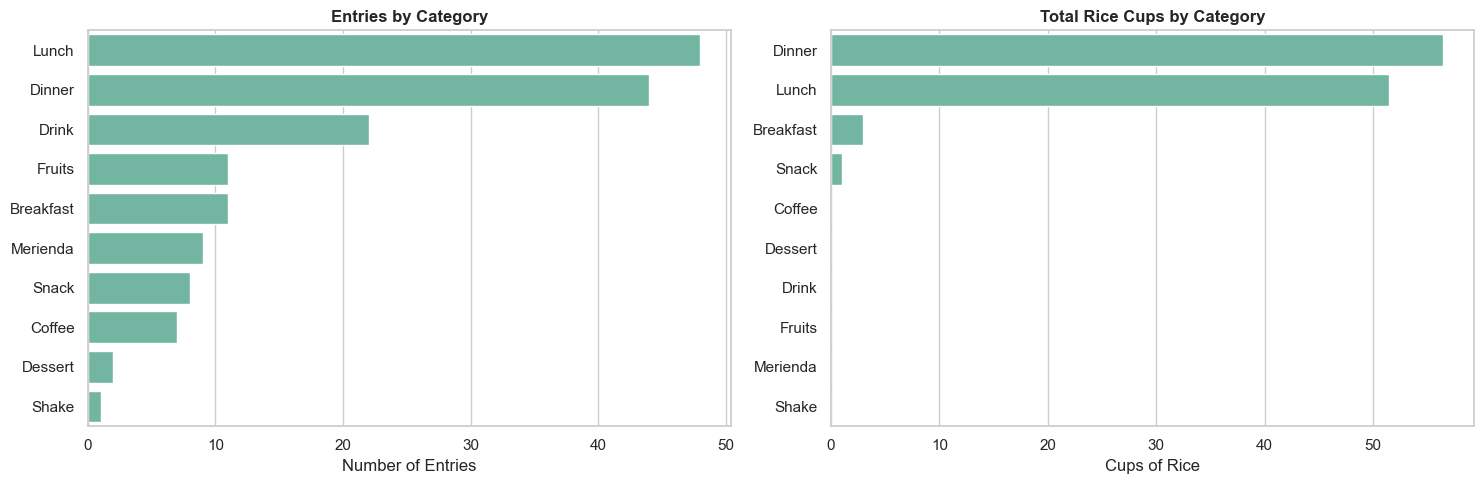

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y="Category", order=category_order, ax=axes[0])
axes[0].set_title("Entries by Category")
axes[0].set_xlabel("Number of Entries")
axes[0].set_ylabel("")

rice_by_category = df.groupby("Category", as_index=False)["Cups of Rice Filled"].sum()
rice_by_category = rice_by_category.sort_values("Cups of Rice Filled", ascending=False)
sns.barplot(data=rice_by_category, y="Category", x="Cups of Rice Filled", ax=axes[1])
axes[1].set_title("Total Rice Cups by Category")
axes[1].set_xlabel("Cups of Rice")
axes[1].set_ylabel("")

plt.tight_layout()

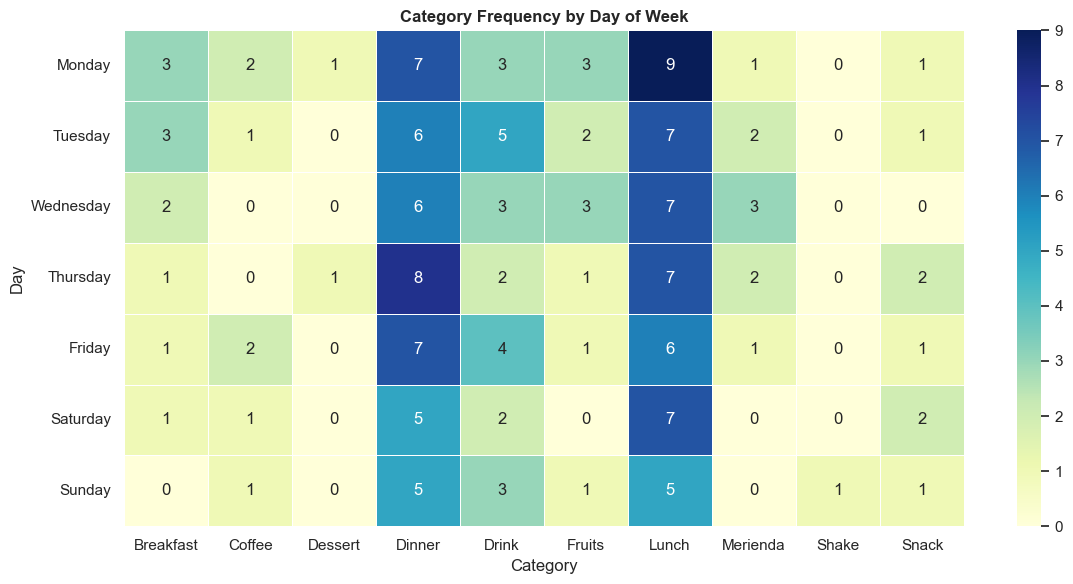

In [24]:
category_day = pd.crosstab(df["Day"], df["Category"]).reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(category_day, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title("Category Frequency by Day of Week")
plt.xlabel("Category")
plt.ylabel("Day")
plt.tight_layout()

## Rice Intake Over Time

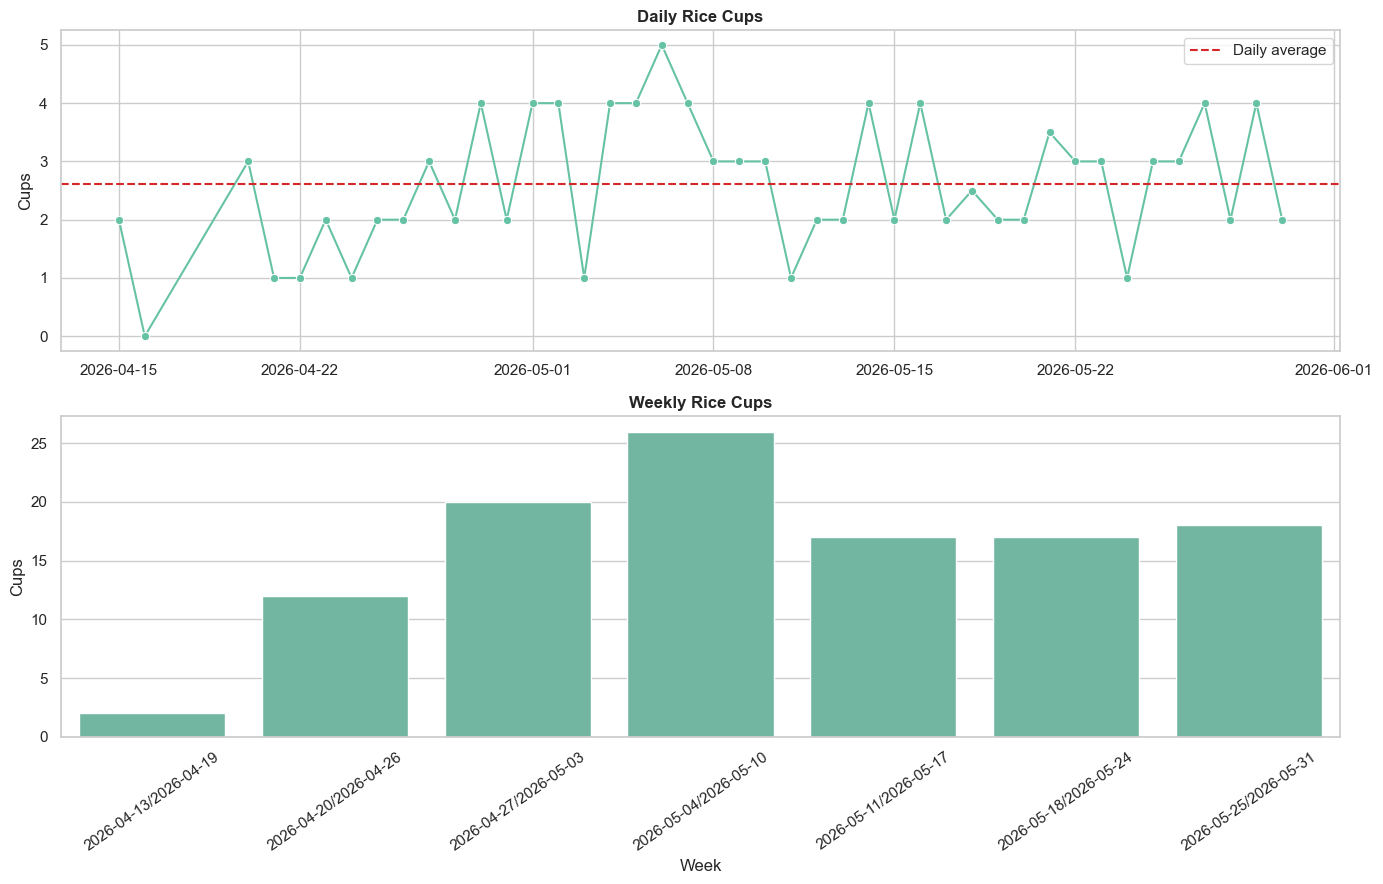

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

sns.lineplot(data=daily, x="Date", y="rice_cups", marker="o", ax=axes[0])
axes[0].axhline(daily["rice_cups"].mean(), color="tab:red", linestyle="--", label="Daily average")
axes[0].set_title("Daily Rice Cups")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cups")
axes[0].legend()

weekly = df.groupby("Week", as_index=False)["Cups of Rice Filled"].sum()
sns.barplot(data=weekly, x="Week", y="Cups of Rice Filled", ax=axes[1])
axes[1].set_title("Weekly Rice Cups")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Cups")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()

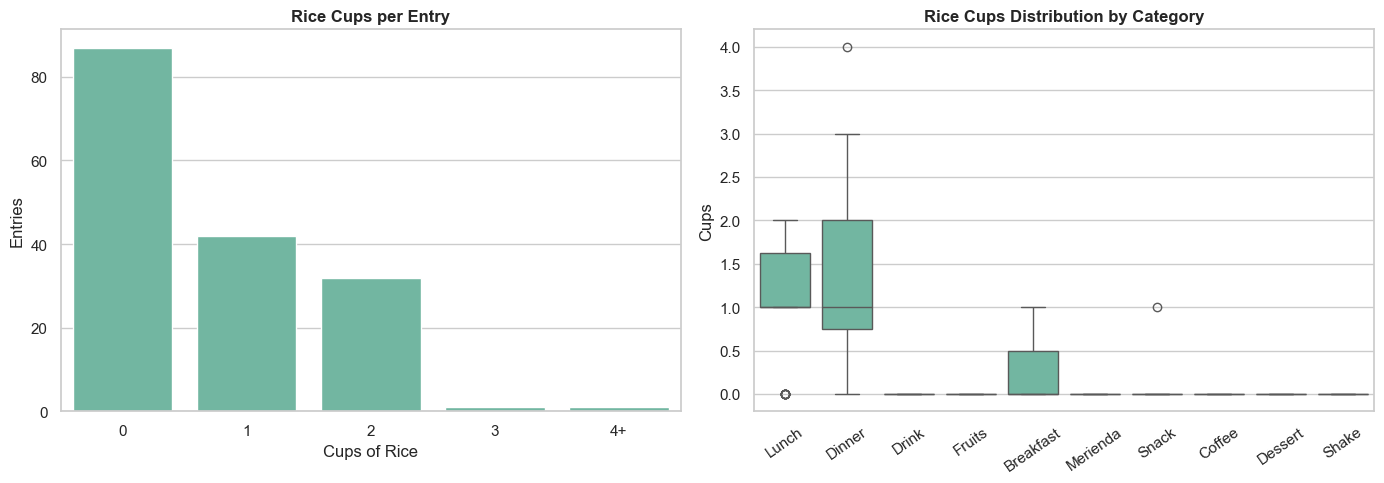

In [26]:
rice_dist = df.copy()
rice_dist["Rice Cup Bin"] = pd.cut(
    rice_dist["Cups of Rice Filled"],
    bins=[-0.1, 0, 1, 2, 3, np.inf],
    labels=["0", "1", "2", "3", "4+"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=rice_dist, x="Rice Cup Bin", ax=axes[0])
axes[0].set_title("Rice Cups per Entry")
axes[0].set_xlabel("Cups of Rice")
axes[0].set_ylabel("Entries")

sns.boxplot(data=df, x="Category", y="Cups of Rice Filled", order=category_order, ax=axes[1])
axes[1].set_title("Rice Cups Distribution by Category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cups")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()

## Dish Themes

The dish text is free-form, so this section uses the broader keyword taxonomy from the generated EDA code. These are approximate labels based only on dish names, not full ingredients, calories, or nutrition data.

In [27]:
patterns = {
    "Pork": r"\b(?:pork|sisig|humba|liempo|tocino|porkchop|menchi|chashu|tonkatsu|katsudon)\b",
    "Chicken": r"\b(?:chicken|inasal|mcdo|cordon)\b",
    "Fish/Seafood": r"\b(?:fish|bangus|tuna|daing|mackerel|seafood|crab|salmon|shrimp)\b",
    "Egg": r"\b(?:egg|eggs|shakshuka|omelette|omelet)\b",
    "Beef": r"\b(?:beef|pares|burger steak|burger)\b",
    "Tofu/Plant Protein": r"\b(?:tofu|tokwa|beans|mongo|monggo)\b",
    "Vegetable Mention": r"\b(?:vegetable|vegetables|gulay|zucchini|carrot|carrots|puso ng saging|talong|kangkong|sayote|green beans|mushroom|tomato|cucumber|togue|enoki|pechay)\b",
    "Fruit Mention": r"\b(?:watermelon|orange|oranges|mango|blueberry|banana|fruit|fruits|apple|grapes|lemon)\b",
    "Fried/Fast Food": r"\b(?:fried|jollibee|mcdo|mcdonald|burger|fries|pizza|donut|krispy|kreme|yabu|tonkatsu|katsu|spam)\b",
    "Sweet Drink/Dessert": r"\b(?:royal|sprite|mountain dew|gatorade|shake|latte|sugar|coffeemate|dessert|cheesecake|butterscotch|donut|maja|graham|ice cream|milk tea|coke)\b",
    "Coffee/Caffeine": r"\b(?:nescafe|coffee|latte|americano|cappuccino|espresso)\b",
    "Bread/Noodles/Pasta": r"\b(?:bread|pasta|spaghetti|sphagetti|pansit|noodle|noodles|gimbap|sandwich|ramen|carbonara)\b",
}

theme_df = df[["Date", "Category", "Dish", "Cups of Rice Filled"]].copy()
dish_lower = theme_df["Dish"].str.lower().fillna("")

for theme, pattern in patterns.items():
    theme_df[theme] = dish_lower.str.contains(pattern, na=False)

theme_counts_entries = (
    theme_df[list(patterns)]
    .sum()
    .sort_values(ascending=False)
    .rename("Rows")
    .reset_index()
    .rename(columns={"index": "Theme detected in dish text"})
)

theme_counts_days = (
    theme_df.groupby("Date")[list(patterns)]
    .any()
    .sum()
    .sort_values(ascending=False)
    .rename("Days")
    .reset_index()
    .rename(columns={"index": "Theme detected in dish text"})
)

display(theme_counts_entries)
display(theme_counts_days)

,Theme detected in dish text,Rows
0,Pork,35
1,Sweet Drink/Dessert,30
2,Fried/Fast Food,27
3,Fish/Seafood,24
4,Chicken,19
5,Fruit Mention,19
6,Egg,18
7,Vegetable Mention,17
8,Coffee/Caffeine,17
9,Bread/Noodles/Pasta,17


,Theme detected in dish text,Days
0,Pork,26
1,Sweet Drink/Dessert,22
2,Fried/Fast Food,20
3,Fish/Seafood,19
4,Fruit Mention,17
5,Egg,16
6,Coffee/Caffeine,16
7,Chicken,14
8,Bread/Noodles/Pasta,13
9,Vegetable Mention,12


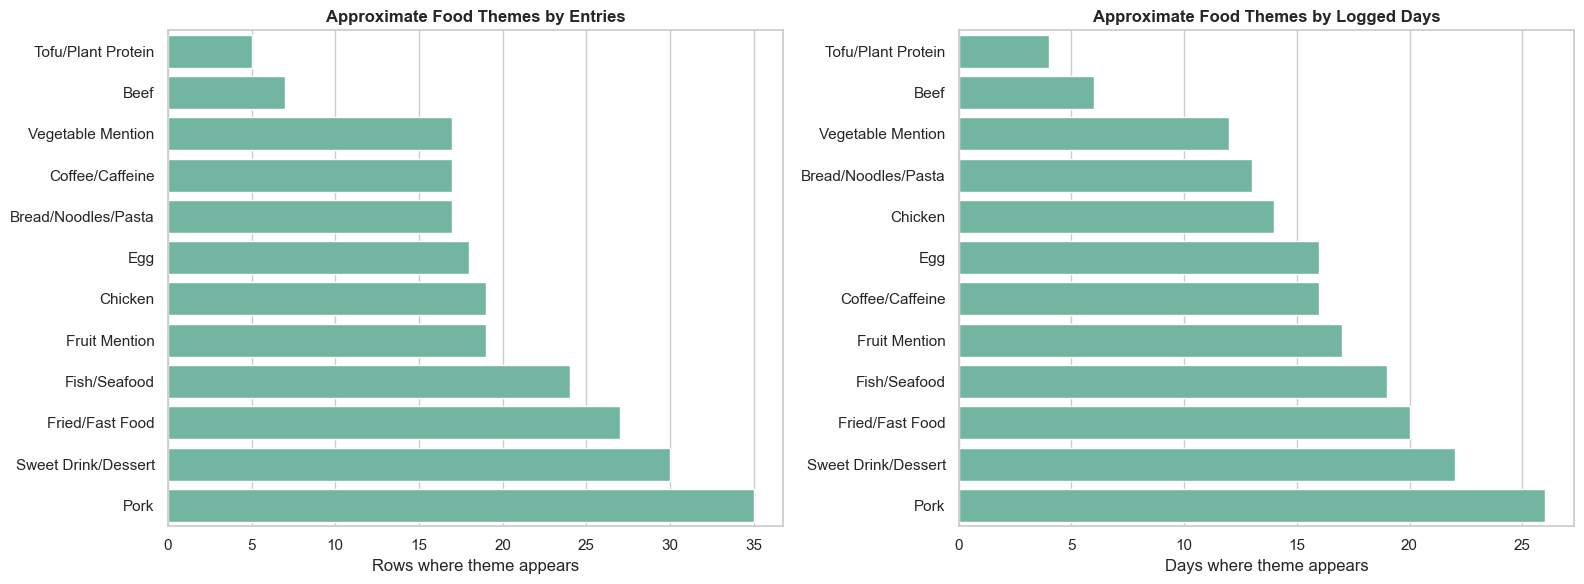

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

entry_plot = theme_counts_entries.sort_values("Rows")
sns.barplot(data=entry_plot, x="Rows", y="Theme detected in dish text", ax=axes[0])
axes[0].set_title("Approximate Food Themes by Entries")
axes[0].set_xlabel("Rows where theme appears")
axes[0].set_ylabel("")

day_plot = theme_counts_days.sort_values("Days")
sns.barplot(data=day_plot, x="Days", y="Theme detected in dish text", ax=axes[1])
axes[1].set_title("Approximate Food Themes by Logged Days")
axes[1].set_xlabel("Days where theme appears")
axes[1].set_ylabel("")

plt.tight_layout()

In [29]:
top_dishes = (
    df["Dish"]
    .value_counts()
    .head(15)
    .rename_axis("Dish")
    .reset_index(name="entries")
)

top_dishes

,Dish,entries
0,Watermelon,3
1,"Cordon Bleu, Small Potatoes, Butterscotch",2
2,"Zucchini, Smothered Porkchop",2
3,Seasalt Spanish Latte,2
4,Miso Soup,2
5,2 Egg Sandwich and Potatoes,2
6,Sphagetti and 1 Bread,2
7,Smothered Porkchop,2
8,Gatorade,2
9,"4 Nescafe Sticks and 2 Tablets of Sugar, 6 Cof...",2


## High-Rice And Dense Logging Days

In [30]:
high_rice_days = daily.sort_values(["rice_cups", "entries"], ascending=False).head(10)
high_rice_days

,Date,entries,categories,rice_cups
18,2026-05-06,3,3,5.0
16,2026-05-04,6,4,4.0
17,2026-05-05,5,5,4.0
11,2026-04-29,4,4,4.0
19,2026-05-07,4,4,4.0
26,2026-05-14,3,3,4.0
39,2026-05-27,3,3,4.0
41,2026-05-29,3,3,4.0
13,2026-05-01,2,2,4.0
14,2026-05-02,2,2,4.0


In [31]:
dense_days = daily.sort_values(["entries", "rice_cups"], ascending=False).head(10)
dense_days

,Date,entries,categories,rice_cups
32,2026-05-20,7,6,2.0
16,2026-05-04,6,4,4.0
37,2026-05-25,6,5,3.0
17,2026-05-05,5,5,4.0
33,2026-05-21,5,4,3.5
9,2026-04-27,5,4,3.0
20,2026-05-08,5,4,3.0
38,2026-05-26,5,4,3.0
30,2026-05-18,5,3,2.5
5,2026-04-23,5,4,2.0


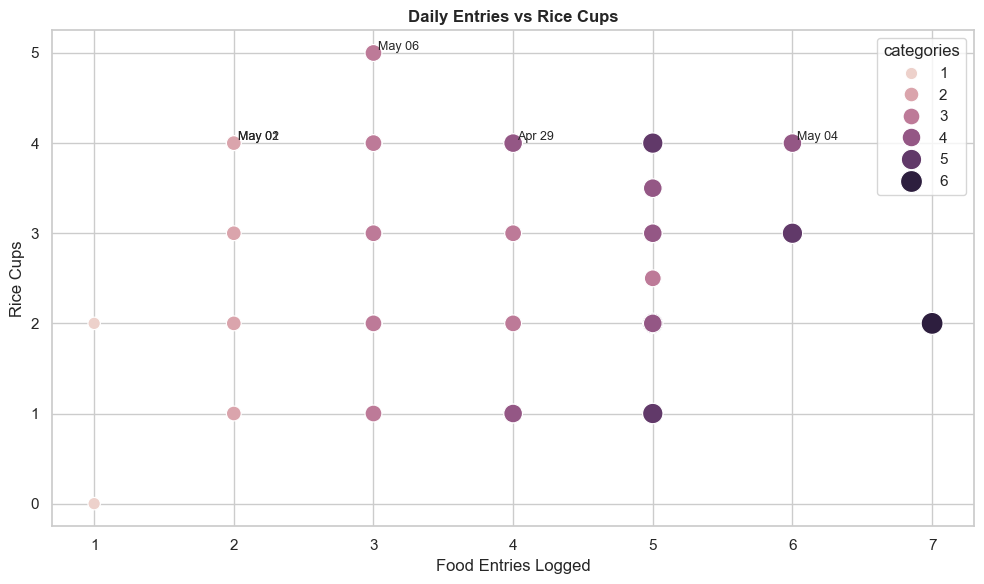

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily, x="entries", y="rice_cups", size="categories", hue="categories", sizes=(80, 250))
for _, row in daily.nlargest(5, "rice_cups").iterrows():
    plt.text(row["entries"] + 0.03, row["rice_cups"] + 0.03, row["Date"].strftime("%b %d"), fontsize=9)
plt.title("Daily Entries vs Rice Cups")
plt.xlabel("Food Entries Logged")
plt.ylabel("Rice Cups")
plt.tight_layout()

## Key Findings

### 1. Food logging was consistent

The food log covers **April 15 to May 30, 2026**, with **163 logged rows** across **43 logged days**. Out of the 46 calendar days covered, only **April 17, April 18, and April 19** had no food entries.

From **April 20 to May 30**, the food log shows a continuous **41-day logging streak**, which makes the dataset reliable enough for identifying eating patterns.

### 2. Lunch and dinner were the most frequently logged meal types

The most common categories were **Lunch** and **Dinner**. Lunch appeared in **48 entries**, while dinner appeared in **44 entries**.

| Category | Entries | Share of Total Logs |
|---|---:|---:|
| Lunch | 48 | 29.4% |
| Dinner | 44 | 27.0% |
| Drink | 22 | 13.5% |
| Breakfast | 11 | 6.7% |
| Fruits | 11 | 6.7% |

Lunch appeared on all **43 logged days**, while dinner appeared on **37 logged days**. Breakfast appeared on only **10 days**, suggesting that breakfast was either skipped frequently or not consistently recorded.

### 3. Rice intake increased from April to May

A total of **112 cups of rice** was logged during the period. The average rice intake was **2.60 cups per logged day**.

Rice intake increased noticeably from April to May.

| Month | Logged Days | Total Cups of Rice | Average Rice per Logged Day | High-Rice Days |
|---|---:|---:|---:|---:|
| April | 13 | 25 cups | 1.92 cups | 1 |
| May | 30 | 87 cups | 2.90 cups | 10 |

A high-rice day was defined as a day with **4 or more cups of rice**. May had significantly more high-rice days than April.

The highest rice intake was recorded on **May 6**, with **5 cups of rice**. There was also a **7-day streak from May 4 to May 10** where rice intake was at least **3 cups per day**.

### 4. Drinks, coffee, shakes, and sweet items appeared frequently

The combined categories of **Drink**, **Coffee**, and **Shake** accounted for **30 entries**, or approximately **18.4%** of all logged rows.

Keyword-based analysis also detected sweet drink or dessert-related items on **22 out of 43 logged days**. These included items such as soft drinks, Gatorade, shakes, sweet coffee, sugar, Coffeemate, donuts, and desserts.

This suggests that sugary drinks and sweet items were recurring parts of the food pattern.

### 5. Fruit and vegetable intake was present but inconsistent

Fruit-category entries appeared on **11 days**, while broader fruit-related keywords appeared on **17 days**. Vegetable-related keywords appeared on only **11 days**.

There was a **9-day streak without fruit mentions** from **May 9 to May 17**. There was also a **10-day streak without vegetable mentions** from **April 23 to May 2**.

This suggests that fruits and vegetables were included occasionally, but not consistently enough to appear as daily food habits.

### 6. Pork was the most frequent protein source

Keyword-based food theme detection showed that pork appeared most frequently among the protein sources.

| Food Theme | Number of Rows |
|---|---:|
| Pork | 34 |
| Fish/Seafood | 22 |
| Chicken | 19 |
| Egg | 18 |
| Beef | 7 |
| Tofu/Plant Protein | 5 |

The food log shows some protein variety, but the protein pattern leaned heavily toward pork. Tofu and plant-based protein sources appeared rarely.

### 7. Fried and fast-food-related items appeared often

Fried or fast-food-related keywords appeared in **28 rows** and on **21 out of 43 logged days**.

This does not mean that every item was unhealthy, but it suggests that fried, processed, or restaurant-style meals were common in the food pattern.

### 8. Daily food log volume and rice intake were moderately related

Days with more food entries often had higher rice intake, but the relationship was not perfectly consistent.

Some days had many logged entries but only moderate rice intake, while some days had fewer entries but higher rice intake. This suggests that rice intake depends more on the type of meals eaten rather than simply the number of logged food items.

---

## Recommendations

### 1. Separate meal timing from food type in the tracker

The current `Category` column mixes meal timing and food type. For example, `Lunch` and `Dinner` describe when the food was eaten, while `Drink`, `Coffee`, and `Fruits` describe what type of food or drink was consumed.

A better structure would be:

| Column | Purpose |
|---|---|
| `Meal Type` | Identifies when the item was eaten |
| `Food Group` | Identifies the main nutritional category |
| `Protein Source` | Identifies the main protein source |
| `Cooking Method` | Identifies how the food was prepared |
| `Drink Type` | Identifies the type of beverage |
| `Health Tag` | Adds quick nutrition-related labels |

Recommended final columns:

| Column |
|---|
| Date |
| Dish |
| Meal Type |
| Food Group |
| Protein Source |
| Cooking Method |
| Drink Type |
| Health Tag |
| Cups of Rice |
| Notes |

This structure would make future analysis cleaner and more useful.

### 2. Use a balanced plate structure for lunch and dinner

Most lunch and dinner meals should ideally include:

- **Rice or another carbohydrate source**
- **Protein**
- **Vegetables**
- **Water or a low-sugar drink**

A practical target is to include at least **one vegetable component** in either lunch or dinner every day, then gradually increase this to both meals when possible.

### 3. Stabilize rice intake

Rice intake increased from April to May, with more high-rice days appearing in May.

A practical starting target is:

- **1 cup of rice per main meal as the default**
- Add more rice only when the meal lacks other filling components, such as protein or vegetables
- Be more mindful of rice portions on days with fried food, fast food, pork-heavy meals, or sugary drinks

This can help make rice intake more consistent without removing rice from the diet.

### 4. Increase fruit intake consistency

Fruit appeared in the food log, but not consistently. A realistic improvement target is:

- Add **1 fruit serving per day**
- Use fruit as a snack or dessert replacement
- Keep easy fruit options available, such as banana, orange, watermelon, apple, mango, or grapes

The goal is not necessarily to increase the number of fruit entries immediately, but to reduce long streaks without fruit.

### 5. Increase vegetable frequency

Vegetable mentions appeared on only **11 logged days**. A practical target is:

- Add vegetables to at least **one main meal per day**
- Prioritize simple and accessible vegetables, such as kangkong, pechay, sayote, talong, cucumber, tomatoes, carrots, or mixed vegetables
- Add a `Vegetable serving` tag in the tracker to make this easier to monitor

The main goal is to make vegetables a regular part of meals instead of an occasional add-on.

### 6. Reduce sugary drinks gradually

Sweet drink and dessert-related items appeared on **22 out of 43 logged days**. This is one of the clearest improvement areas.

Suggested steps:

- Replace soft drinks with water on regular days
- Keep sweet drinks for selected meals or occasions
- Reduce sugar or Coffeemate in coffee gradually
- Track sugary drinks using a `Sugary drink` health tag

A realistic starting goal is to reduce sugary drinks to **2–3 days per week**.

### 7. Diversify protein sources

Pork was the most frequent protein source in the food log. Protein variety can be improved by rotating more often among:

- Fish or seafood
- Chicken
- Eggs
- Tofu or tokwa
- Monggo or beans
- Beef in moderation

A practical weekly target is:

- Fish or seafood: **2–3 times per week**
- Chicken or eggs: **2–3 times per week**
- Tofu or plant-based protein: **at least 2 times per week**
- Pork: reduce frequency where possible, especially when meals are fried or processed

### 8. Reduce fried and fast-food frequency

Fried and fast-food-related items appeared on nearly half of the logged days.

Suggested approach:

- Limit fried or fast-food-style meals to **2–3 times per week**
- Pair fried meals with vegetables and water
- Avoid combining fried food, sugary drinks, and extra rice in the same meal when possible
- Use cooking method tags such as `Fried`, `Grilled`, `Boiled`, `Steamed`, or `Soup/Stew`

The goal is not complete restriction, but better frequency control.

### 9. Improve breakfast tracking

Breakfast appeared on only **10 days**. This may mean breakfast was skipped or not consistently logged.

Suggested tracker improvement:

- Add a `Skipped` option for breakfast
- Record simple breakfasts such as coffee, bread, eggs, oatmeal, fruit, or leftovers
- Track whether breakfast affects hunger and rice intake later in the day

This can help determine whether skipped breakfast is connected to higher rice intake during lunch or dinner.

### 10. Add health tags for easier future EDA

A `Health Tag` column would make the next analysis more meaningful.

Recommended health tags:

| Health Tag | Use Case |
|---|---|
| `Balanced meal` | Meal includes rice/carbs, protein, and vegetables |
| `High rice` | Day or meal includes unusually high rice intake |
| `Sugary drink` | Soft drinks, sweet coffee, shakes, or sweetened drinks |
| `Fried food` | Fried dishes or deep-fried items |
| `Fast food` | Restaurant or fast-food meals |
| `Fruit serving` | Any fruit consumed |
| `Vegetable serving` | Any vegetable consumed |
| `Protein-rich` | Meal has a clear protein source |
| `Low vegetable` | Meal lacks vegetables |
| `Home-cooked` | Meal prepared at home |
| `Restaurant/Takeout` | Food bought outside |

Multiple tags can be used in one row.

Example:

```text
Fried food; High rice; Low vegetable

## Deeper Dish-Name Analysis

### Methodological Note

The analysis below is based on keyword detection from the `Dish` column. Counts are approximate because dish names do not always list complete ingredients, serving sizes, cooking methods, or exact preparation details. Some rows also contain multiple dishes in one cell, so several tags can apply to the same row.

---

## 1. Dish Names Contain Much More Information Than the Current Category Column

The `Category` column mostly identifies meal timing, such as `Lunch`, `Dinner`, `Breakfast`, or `Merienda`. However, the `Dish` column contains richer information about:

- Main protein source
- Cooking method
- Cuisine or dish style
- Carb source
- Fruit or vegetable presence
- Sugary drinks and desserts
- Restaurant or fast-food items
- Meal complexity
- Repeated food habits

Because of this, deeper analysis should treat `Dish` as a semi-structured text field rather than a simple food name.

---

## 2. Many Dish Names Are Compound Meals

A large portion of the dish names contain multiple food items in one row.

| Metric | Value |
|---|---:|
| Total rows | 163 |
| Rows with compound markers such as commas, `and`, `&`, or colon | 72 |
| Share of compound rows | 44.2% |
| Rows with quantity indicators such as `1`, `2`, `pcs`, `cups`, `sticks`, `slice` | 62 |
| Share of rows with quantity indicators | 38.0% |
| Average approximate components per dish row | 1.77 |

Compound dish names became much more common in May.

| Month | Rows | Average Components per Row | Compound Rows | Compound Share | Quantity Rows | Quantity Share |
|---|---:|---:|---:|---:|---:|---:|
| April 2026 | 48 | 1.25 | 7 | 14.6% | 9 | 18.8% |
| May 2026 | 115 | 1.99 | 65 | 56.5% | 50 | 43.5% |

### Interpretation

Dish logging became more detailed in May. Instead of logging only the main dish, many entries started including sides, desserts, drinks, and ingredients. This is useful, but it also makes analysis harder unless each dish component is separated.

For example:

| Current Dish Entry | Issue | Better Structure |
|---|---|---|
| `Cordon Bleu, Small Potatoes, Butterscotch` | Main dish, side, and dessert are in one cell | Split into `Cordon Bleu`, `Small Potatoes`, and `Butterscotch` |
| `Fish Fillet with Tartar Sauce and Sauted Vegetables... Small Lemon Cheesecake` | Main dish, sauce, vegetables, and dessert are combined | Split into main, sauce, vegetable side, and dessert |
| `Liempo, Pansit, 1 pc Chicken Mcdo` | Multiple proteins and carb sources are combined | Split into `Liempo`, `Pansit`, and `Chicken Mcdo` |
| `4 Nescafe Sticks, 6 Coffee Mate, 2 Artificial Tablet Sugar` | Drink and additives are combined | Separate coffee base, creamer count, and sweetener count |
| `Pork Tonkatsu and Sinigang na Bangus` | Two main dishes are combined | Split into `Pork Tonkatsu` and `Sinigang na Bangus` |

---

## 3. Most Common Dish Families and Food Signals

The dish names show several recurring dish families. These are not mutually exclusive; one dish can belong to multiple families.

| Dish Family / Signal | Rows | Days | Main Observation |
|---|---:|---:|---|
| Breakfast bread/egg-type dishes | 21 | 15 | Bread, egg, sandwich, pandesal, French toast, and similar items appear often. |
| Chicken dishes | 20 | 15 | Chicken appears across simple meals, fast food, inasal, cordon bleu, and mixed dishes. |
| Bangus/fish-related dishes | 18 | 14 | Fish appears through bangus, tuna, mackerel, fish fillet, fish sausage, and seafood dishes. |
| Nescafe / coffee drinks | 17 | 16 | Coffee is frequent and often includes sugar, Coffeemate, or milk. |
| Soup / stew / curry dishes | 14 | 13 | Sinigang, caldereta, curry, hotpot, ginataang dishes, and soup appear regularly. |
| Soft or sweet drinks | 14 | 12 | Coke, Sprite, Royal, Gatorade, fruit tea, shake, and similar drinks appear repeatedly. |
| Dessert / pastry sweets | 13 | 9 | Donuts, cakes, cheesecake, butterscotch, grahams, and maja blanca appear in several entries. |
| Palabok / pansit / pasta / noodles | 12 | 11 | Noodles and pasta appear frequently, often outside the rice count. |
| Sisig variants | 9 | 9 | Sisig is one of the strongest repeated dish families. |
| Gimbap / sushi / nori dishes | 7 | 7 | Gimbap and sushi-style dishes appear several times, especially in May. |
| Tonkatsu / katsudon / katsu-style dishes | 6 | 6 | Katsu-style meals appear repeatedly and are often paired with rice. |
| Porkchop / smothered porkchop | 6 | 5 | Porkchop appears in both simple and vegetable-paired meals. |
| Fried rice | 4 | 4 | Fried rice appears as kimchi fried rice, steak kimchi fried rice, and egg fried rice. |
| Tofu / tokwa / togue | 4 | 4 | Plant-based protein appears rarely compared with meat-based dishes. |

---

## 4. Protein Source Analysis

A refined keyword-based estimate shows the following protein-source pattern:

| Protein Source | Rows | Days |
|---|---:|---:|
| Pork | 35 | 26 |
| Fish/Seafood | 26 | 20 |
| Chicken | 20 | 15 |
| Egg | 18 | 16 |
| Beef | 7 | 7 |
| Tofu/Tokwa | 4 | 4 |

### Interpretation

Pork is the dominant protein signal. It appears in many forms, including:

- Sisig
- Pork tonkatsu
- Pork katsudon
- Porkchop
- Pork caldereta
- Pork adobo
- Pork humba
- Dinakdakan
- Bicol Express
- Liempo
- Pork dumplings
- Pork floss bread

Fish and seafood also appear regularly, especially through:

- Bangus
- Tuna
- Mackerel
- Daing
- Fish fillet
- Fish sausage
- Shrimp
- Crab
- Fish cake

Chicken appears in both home-style and fast-food-style meals, such as:

- Chicken
- Garlic buttered chicken
- Chicken sisig
- Chicken Mcdo
- Cordon Bleu
- Chicken afritada
- Pecho/Paa inasal
- Marinated chicken breast

Tofu and plant-based protein are much less frequent. Tofu/tokwa/togue only appeared in **4 rows across 4 days**.

---

## 5. Multi-Protein Meals Are Common

There were **17 rows** with at least two protein signals. These rows are important because they can inflate protein counts if the dish is not split into components.

Examples include:

| Date | Dish |
|---|---|
| April 15 | `Eggs, Sisig, and Tokwa` |
| April 22 | `Bicol Express, Fried Tofu, and Ginataang Gulay` |
| April 29 | `Uncle Moe’s Beef and Chicken Kebab, 3 Kofta Balls, and 1 Pita Wrap` |
| May 10 | `Liempo, Pansit, 1 pc Chicken Mcdo` |
| May 13 | `Hainanese Chicken & 4 Pork Dumplings` |
| May 16 | `3 Pcs Mandu and Egg and Chicken Poppers` |
| May 22 | `Pork Tonkatsu, Fish Sausage` |
| May 25 | `Tuna Sisig and Fried Egg` |
| May 26 | `Sinigang na Bangus, Pork Sisig, Kilawing Tuna` |
| May 27 | `Pork Tonkatsu and Sinigang na Bangus` |
| May 29 | `Chicken Afritada, Pork Humba` |
| May 29 | `1 Roll of Gimbap..., Marinated Chicken Breast, and Spam` |

### Interpretation

The food log contains several mixed-protein meals. This is useful nutritionally, but it should be tracked more carefully using separate fields:

| Suggested Field | Purpose |
|---|---|
| `Main Protein` | Primary protein source |
| `Secondary Protein` | Additional protein source |
| `Protein Count` | Number of protein sources in the row |
| `Processed Meat Flag` | Identifies spam, ham, sausage, dumplings, fast-food meat, etc. |

---

## 6. Cooking Method Analysis

Cooking method can be inferred from several dish names.

| Cooking / Preparation Signal | Rows | Days |
|---|---:|---:|
| Fried | 24 | 21 |
| Soup / Stew / Curry | 16 | 14 |
| Grilled / Roasted / Kebab / Inasal | 6 | 5 |
| Sautéed | 4 | 2 |

### Fried Food Pattern

Fried-related items appeared on **21 out of 43 logged days**. Examples include:

- Fried bangus
- Pritong isda
- Kimchi fried rice
- Fried egg
- Egg fried rice
- Tonkatsu
- Katsudon
- Chicken poppers
- Fries
- Spring rolls
- Donuts
- Fast-food chicken

### Soup / Stew / Curry Pattern

Soup, stew, and curry-style dishes also appeared regularly. Examples include:

- Sinigang
- Tinola
- Caldereta
- Indian orange curry
- Miso soup
- Hotpot
- Ginataang dishes
- Bicol Express
- Ramyun
- Sotanghon

### Interpretation

The food pattern is not only fried-heavy. It also includes a meaningful number of soup, stew, and curry dishes. This distinction matters because a dish-level `Cooking Method` column would allow better comparison between fried meals, soup meals, grilled meals, and home-style dishes.

---

## 7. Cuisine and Dish Style Analysis

Cuisine-style signals were also visible in the dish names.

| Cuisine / Style Signal | Rows | Days |
|---|---:|---:|
| Filipino Dish | 37 | 26 |
| Japanese/Korean-Inspired | 24 | 19 |
| Western/Other | 21 | 15 |
| Fast Food / Restaurant Brand | 11 | 11 |

### Filipino Dish Pattern

Common Filipino or Filipino-style dishes include:

- Sisig
- Tokwa
- Pares
- Ginataang gulay
- Bicol Express
- Daing
- Palabok
- Pork sinigang
- Pritong isda
- Tinola
- Puso ng saging
- Adobo
- Liempo
- Bangus
- Dinakdakan
- Pandesal
- Maja blanca
- Afritada
- Humba
- Inasal

### Japanese/Korean-Inspired Pattern

Japanese and Korean-inspired dishes became especially visible in May. Examples include:

- Tonkatsu
- Katsudon
- Yabu Menchi Set
- Kimchi fried rice
- Gimbap
- Miso soup
- Sukiyaki
- Enoki rolls
- Mandu
- Ramyun
- Sushi
- Nori balls
- Kewpie
- Chashu
- Ramen

### Western / Other Pattern

Western or mixed-style dishes include:

- Pizza
- Pasta
- Burger steak
- Burger
- Cordon Bleu
- French toast
- Kebab
- Pita wrap
- Cheesecake
- Carrot cake
- Mac n cheese
- Sandwich

### Interpretation

The food pattern is cuisine-diverse. Filipino dishes are the strongest base, while Japanese/Korean-inspired foods and Western/restaurant-style foods appear frequently in May. A `Cuisine/Style` column would be helpful for identifying which cuisine patterns are associated with higher rice intake, fried food frequency, or sugary drink pairings.

---

## 8. Carbohydrate Analysis Beyond the Rice Column

The `Cups of Rice` column captures plain rice intake, but many dish names contain other carbohydrate sources.

Carb-related dish signals appeared in **42 rows**. Among these, **25 rows had 0 cups of rice recorded**, despite still being carb-heavy.

Examples of carb-heavy rows with `0` cups of rice:

| Dish |
|---|
| `Palabok and Monay` |
| `Jollibee Supreme Burger Steak` |
| `Burger with Atay` |
| `Palabok` |
| `Tonkotsu Ramen Kyukyu` |
| `Gimbap` |
| `Pesto Chicken Wrap` |
| `3 Pizza Slices and 1 Chicken` |
| `Pesto Pasta` |
| `Pasta and Wheat Bread` |
| `4 pcs Pandesal and Scrambled Egg` |
| `Shakshuka & 1 Bread` |
| `Pansit and Half Toasted Bread` |
| `Egg and Bread` |
| `Sotanghon` |
| `2 Egg Sandwich and Potatoes` |
| `French Toast with Fruits and Maple Syrup` |
| `Sphagetti and 1 Bread` |
| `Shim Ramyun w/ 1 Egg` |
| `Hawaiian Pizza, Shrimp Aglia Olio, and Mac n Cheese` |
| `2 Pcs Spring in the City/Pork Floss Bread` |

### Interpretation

Rice intake is not the same as total carbohydrate intake. Several meals with `0` cups of rice still contain noodles, bread, pasta, pizza, potatoes, burger buns, wraps, or rice-based items such as gimbap.

For better analysis, the tracker should include:

| Suggested Field | Example Values |
|---|---|
| `Carb Base` | Plain rice, fried rice, gimbap/sushi rice, noodles, pasta, bread, wrap, potato, pastry, none |
| `Carb Serving Estimate` | None, low, moderate, high |
| `Rice Included in Dish` | Yes/No |
| `Separate Plain Rice` | Numeric cups |

---

## 9. Coffee, Sweet Drinks, and Sweet Add-ons

Drink-related information is highly detailed in the dish names.

| Signal | Rows | Days |
|---|---:|---:|
| Coffee | 17 | 16 |
| Sweetened coffee | 14 | 13 |
| Sugary or sweet drink | 27 | 20 |
| Dessert / sweets | 15 | 10 |
| Dairy / creamy items | 23 | 18 |

### Repeated Coffee Pattern

The normalized coffee pattern `Nescafe + sugar + Coffeemate` appeared repeatedly.

Common coffee-related entries include:

- `Nescafe 2 Sticks and 2 Teaspoons of Sugar`
- `2 Nescafe Sticks and 1 Tablet of Sugar, 3 Coffeemate`
- `4 Nescafe Sticks and 2 Tablets of Sugar, 6 Coffeemate`
- `4 Nescafe Sticks, 6 Coffee Mate, 2 Artificial Tablet Sugar`
- `2 Nescafe Sticks with Milk`
- `4 Nescafe Sticks with Milk`
- `Spanish Latte`
- `Seasalt Spanish Latte`

### Interpretation

Coffee is not just a beverage category. It contains measurable add-ons such as sugar, Coffeemate, milk, and artificial sweetener. These should be extracted into separate fields.

Recommended coffee-specific fields:

| Field | Purpose |
|---|---|
| `Drink Base` | Coffee, tea, soft drink, milk tea, shake, fruit tea |
| `Coffee Sticks` | Number of Nescafe sticks |
| `Sugar Amount` | Number of teaspoons/tablets |
| `Creamer Amount` | Number of Coffeemate servings |
| `Milk Added` | Yes/No |
| `Sweetened Drink Flag` | Yes/No |

---

## 10. Fruit and Vegetable Mentions

Fruit and vegetable mentions are present but inconsistent.

| Signal | Rows | Days |
|---|---:|---:|
| Fruit Mention | 23 | 20 |
| Vegetable Mention | 23 | 18 |

### Fruit Examples

- Watermelon
- Orange
- Grapes
- Dragonfruit
- Pomelo
- Mango
- Blueberry
- Melon
- Avocado
- Lemon
- Fruit tea

### Vegetable Examples

- Puso ng saging
- Ginataang gulay
- Togue
- Cucumber
- Seaweed
- Nori
- Kimchi
- Tomato
- Onion
- Corn
- Carrots
- Zucchini
- Green beans
- Lettuce/salad bowl
- Vegetables

### Interpretation

Fruit and vegetable mentions do not always mean full servings. Some are main sides, while others are small ingredients or garnishes.

Examples:

| Dish | Vegetable/Fruit Role |
|---|---|
| `Fish Fillet with... Sauted Vegetables` | Clear vegetable side |
| `Zucchini, Smothered Porkchop` | Vegetable side with pork |
| `Gimbap: Spam, Cucumber, Crab Stick, Seaweed` | Vegetable ingredients, but likely small portions |
| `Tuna, Kimchi, Nori Balls` | Vegetable/seaweed components, but not necessarily a full serving |
| `French Toast with Fruits and Maple Syrup` | Fruit included, but sweet component also present |
| `Avocado with Condensed Milk, and Bearbrand Milk` | Fruit present, but sweetened dairy component also present |

A better tracker should distinguish between:

| Field | Example Values |
|---|---|
| `Fruit Present` | Yes/No |
| `Fruit Serving` | None, partial, full, multiple |
| `Vegetable Present` | Yes/No |
| `Vegetable Serving` | None, garnish, partial, full, multiple |

---

## 11. Repeated Dish Names and Normalized Repeats

Exact dish names sometimes repeat, while other dishes repeat with slightly different wording.

### Exact Repeated Entries

| Dish | Count |
|---|---:|
| `Watermelon` | 3 |
| `2 Nescafe Sticks and 1 Tablet of Sugar, 3 Coffeemate` | 2 |
| `4 Nescafe Sticks and 2 Tablets of Sugar, 6 Coffeemate` | 2 |
| `Overnight Meal: Yogurt, Milk, Trail MIxed Nuts, Blueberry, Honey` | 2 |
| `Smothered Porkchop` | 2 |
| `2 Nescafe Sticks and 1 Tablets of Sugar, 3 Coffeemate` | 2 |
| `Fish Fillet with Tartar Sauce and Sauted Vegetables... Small Lemon Cheesecake` | 2 |
| `Sphagetti and 1 Bread` | 2 |
| `Cordon Bleu, Small Potatoes, Butterscotch` | 2 |
| `Jollibee Supreme Burger Steak` | 2 |
| `Zucchini, Smothered Porkchop` | 2 |
| `2 Egg Sandwich and Potatoes` | 2 |
| `Daing` | 2 |
| `Miso Soup` | 2 |
| `Seasalt Spanish Latte` | 2 |
| `Gatorade` | 2 |
| `Fried Bangus` | 2 |

### Normalized Repeated Patterns

After removing quantities and standardizing wording, the strongest repeated pattern was:

| Normalized Pattern | Count |
|---|---:|
| `Nescafe + sugar + Coffeemate` | 6 |
| `Watermelon` | 4 |
| `Gimbap + Spam + Cucumber + Crab + Seaweed` | 2 |
| `Bangus + Onion + Tomato + Saute` | 2 |
| `Fish Fillet + Vegetables + Lemon Cheesecake` | 2 |
| `Egg Sandwich + Potatoes` | 2 |
| `Zucchini + Smothered Porkchop` | 2 |
| `Cordon Bleu + Potatoes + Butterscotch` | 2 |
| `Sphagetti + Bread` | 2 |
| `Miso Soup` | 2 |
| `Fried Bangus` | 2 |
| `Jollibee Supreme Burger Steak` | 2 |

### Interpretation

Repeated patterns show that food behavior is not random. The strongest repeated habits include:

1. Sweetened coffee formulas
2. Pork-based dishes
3. Fish/bangus dishes
4. Gimbap/sushi-style meals
5. Fried or katsu-style meals
6. Bread/egg breakfast-type meals
7. Noodle/pasta/snack meals

---

## Overall Interpretation

The dish names show that the food log is rich enough for a much deeper nutrition and behavior analysis. The strongest dish-name patterns are:

1. Frequent pork-based meals
2. Regular fish/seafood intake
3. Frequent sweetened coffee and sugary drinks
4. Many fried or fast-food-style items
5. Repeated Japanese/Korean-inspired rice-based meals such as gimbap, sushi, kimchi fried rice, and tonkatsu
6. Several Filipino staple dishes such as sisig, sinigang, adobo, bangus, pares, tinola, Bicol Express, and palabok
7. Frequent carb sources outside plain rice, especially noodles, bread, pasta, pizza, and potatoes
8. Vegetable and fruit presence, but often as inconsistent or partial servings
9. Several compound meal entries that should be split for better analysis

The next major improvement should be dish-name standardization. After standardizing dish names and splitting compound entries, the food log can support more accurate weekly dashboards for protein variety, fried food frequency, sweet drink intake, vegetable consistency, carb sources, and repeated dish habits.